# Chapter 4 — Text as Data: Strings, Characters, and Finite Sequences

The previous chapters introduced next-token prediction, the miniature training pipeline, and reliable notebook habits.

This chapter begins the detailed data story by examining the raw material every language model receives.

By the end of the chapter, you will be able to:

- describe a Python string as a finite ordered sequence;
- inspect visible and invisible elements by position;
- explain zero-based indexes and end-exclusive slices;
- build a deterministic character vocabulary;
- encode text as character IDs and decode it exactly;
- count character frequencies; and
- create paired next-character examples.

No model is trained here.

The goal is to represent text carefully enough that later models receive exactly the sequence we intend.

## Strings Are Finite Sequences

A **sequence** is an ordered collection with a finite length.

A Python string is a sequence whose elements are Unicode code points.

This course usually calls each string element a **character** because that term is easier to read.

The Unicode section later in the chapter explains why one displayed symbol is not always one Python string element.

We will use one local fixture containing letters, spaces, punctuation, and a newline:

```text
the dog ran.
the cat sat.
```

In [1]:
text = "the dog ran.\nthe cat sat."

print("Text as displayed:")
print(text)
print("Text with hidden characters visible:")
print(repr(text))
print("Number of string elements:", len(text))

Text as displayed:
the dog ran.
the cat sat.
Text with hidden characters visible:
'the dog ran.\nthe cat sat.'
Number of string elements: 25


## Make Invisible Characters Visible

Normal printing shows text as a reader sees it.

`repr` shows an inspectable representation of spaces, newlines, tabs, and empty strings.

Every position in the fixture contains exactly one string element.

The table below makes spaces, punctuation, and the newline explicit.

In [2]:
print("Position | Character")
print("-" * 24)
for position, character in enumerate(text):
    print(f"{position:>8} | {character!r}")

structural_positions = {
    "spaces": [position for position, character in enumerate(text) if character == " "],
    "newlines": [
        position for position, character in enumerate(text) if character == "\n"
    ],
    "periods": [
        position for position, character in enumerate(text) if character == "."
    ],
}
print("Structural character positions:", structural_positions)

Position | Character
------------------------
       0 | 't'
       1 | 'h'
       2 | 'e'
       3 | ' '
       4 | 'd'
       5 | 'o'
       6 | 'g'
       7 | ' '
       8 | 'r'
       9 | 'a'
      10 | 'n'
      11 | '.'
      12 | '\n'
      13 | 't'
      14 | 'h'
      15 | 'e'
      16 | ' '
      17 | 'c'
      18 | 'a'
      19 | 't'
      20 | ' '
      21 | 's'
      22 | 'a'
      23 | 't'
      24 | '.'
Structural character positions: {'spaces': [3, 7, 16, 20], 'newlines': [12], 'periods': [11, 24]}


## Positions, Indexes, and Slices

A **position** is a location in the sequence.

An **index** is the integer Python uses to access that position.

Indexes begin at 0, so the final valid index is `len(text) - 1`.

A slice `text[start:end]` includes `start` and excludes `end`.

End-exclusive slicing lets adjacent slices meet at one boundary without overlapping.

In [3]:
positions_to_inspect = [0, 3, 7, 11, 12, len(text) - 1]
for position in positions_to_inspect:
    print(f"text[{position}] = {text[position]!r}")

print("text[0:3] =", repr(text[0:3]))
print("text[4:7] =", repr(text[4:7]))
print("text[8:12] =", repr(text[8:12]))
print("text[8:13] =", repr(text[8:13]))

text[0] = 't'
text[3] = ' '
text[7] = ' '
text[11] = '.'
text[12] = '\n'
text[24] = '.'
text[0:3] = 'the'
text[4:7] = 'dog'
text[8:12] = 'ran.'
text[8:13] = 'ran.\n'


## Character Tokens and Vocabulary

Character-level tokenization converts a string directly into a list of its elements.

It preserves spaces, punctuation, and newlines without needing word-boundary rules.

The **character vocabulary** is the set of unique elements observed in the text.

Sorting that set gives deterministic IDs, but the order follows Unicode code-point values rather than linguistic meaning.

Character IDs are arbitrary labels.

Their numeric distances do not express similarity between characters.

In [4]:
characters = list(text)
character_vocabulary = sorted(set(characters))
character_to_id = {
    character: character_id
    for character_id, character in enumerate(character_vocabulary)
}
id_to_character = {
    character_id: character for character, character_id in character_to_id.items()
}

print("Character count:", len(characters))
print("Vocabulary size:", len(character_vocabulary))
print("Character ID | Character")
print("-" * 26)
for character_id, character in enumerate(character_vocabulary):
    print(f"{character_id:>12} | {character!r}")

Character count: 25
Vocabulary size: 14
Character ID | Character
--------------------------
           0 | '\n'
           1 | ' '
           2 | '.'
           3 | 'a'
           4 | 'c'
           5 | 'd'
           6 | 'e'
           7 | 'g'
           8 | 'h'
           9 | 'n'
          10 | 'o'
          11 | 'r'
          12 | 's'
          13 | 't'


## Encode and Decode Without Losing Text

**Encoding** replaces each character with its ID.

**Decoding** replaces each ID with its character and joins the sequence.

A **round trip** succeeds when decoding an encoded string reproduces the original string exactly.

Character-level encoding preserves this fixture's spaces, punctuation, and newline.

In [5]:
def encode_characters(
    text: str,
    character_to_id: dict[str, int],
) -> list[int]:
    return [character_to_id[character] for character in text]


def decode_character_ids(
    character_ids: list[int],
    id_to_character: dict[int, str],
) -> str:
    return "".join(id_to_character[character_id] for character_id in character_ids)


character_ids = encode_characters(text, character_to_id)
decoded_text = decode_character_ids(character_ids, id_to_character)
assert decoded_text == text
print("Character IDs:", character_ids)
print("Decoded text:", repr(decoded_text))
print("Exact round trip succeeds:", decoded_text == text)

Character IDs: [13, 8, 6, 1, 5, 10, 7, 1, 11, 3, 9, 2, 0, 13, 8, 6, 1, 4, 3, 13, 1, 12, 3, 13, 2]
Decoded text: 'the dog ran.\nthe cat sat.'
Exact round trip succeeds: True


## Count Character Frequencies

A frequency count records how often each character occurs.

This is the first step toward models that estimate probabilities from observed counts.

The explicit loop below shows exactly how the dictionary is updated.

The total of all counts must equal the string length because every position is counted once.

In [6]:
def count_characters(text: str) -> dict[str, int]:
    counts: dict[str, int] = {}
    for character in text:
        if character not in counts:
            counts[character] = 0
        counts[character] += 1
    return counts


character_counts = count_characters(text)
for character in sorted(character_counts):
    print(f"{character!r:>6}: {character_counts[character]}")
total_counted_characters = sum(character_counts.values())
assert total_counted_characters == len(text)
print("Total counted:", total_counted_characters)
print("Text length:", len(text))

  '\n': 1
   ' ': 4
   '.': 2
   'a': 3
   'c': 1
   'd': 1
   'e': 2
   'g': 1
   'h': 2
   'n': 1
   'o': 1
   'r': 1
   's': 1
   't': 4
Total counted: 25
Text length: 25


The frequency plot has one specific purpose.

It makes the uneven distribution of characters easier to compare than the count table alone.

Using `repr` for labels keeps the space and newline visible.

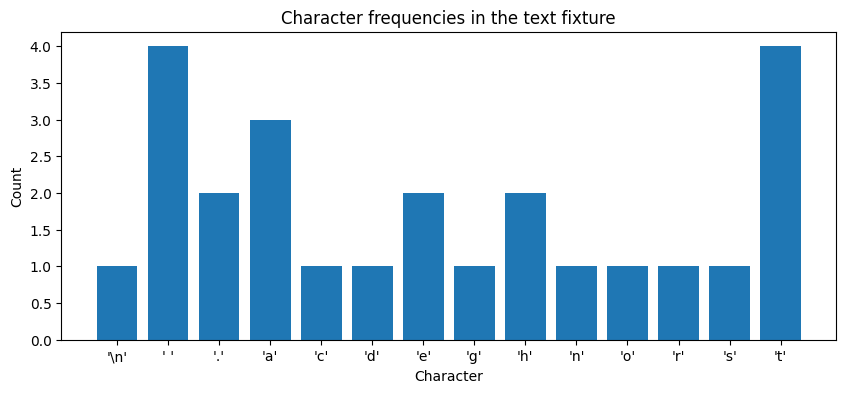

In [7]:
import matplotlib.pyplot as plt

plot_characters = sorted(character_counts)
plot_labels = [repr(character) for character in plot_characters]
plot_counts = [character_counts[character] for character in plot_characters]
plt.figure(figsize=(10, 4))
plt.bar(plot_labels, plot_counts)
plt.xlabel("Character")
plt.ylabel("Count")
plt.title("Character frequencies in the text fixture")
plt.show()

## Build Next-Character Examples

A next-character example pairs a fixed-length context with the character immediately after it.

With text length `N` and context length `C`, this construction produces `N - C` examples.

Keeping each context and target in one tuple prevents separate collections from drifting out of alignment.

The examples around the line boundary show that a newline can be either a target or part of the next context.

In [8]:
def build_next_character_examples(
    text: str,
    context_length: int,
) -> list[tuple[str, str]]:
    if context_length < 1:
        raise ValueError("context_length must be at least 1")
    if context_length >= len(text):
        raise ValueError("context_length must be smaller than the text length")

    examples: list[tuple[str, str]] = []
    for start_position in range(len(text) - context_length):
        target_position = start_position + context_length
        context = text[start_position:target_position]
        examples.append((context, text[target_position]))
    return examples


context_length = 4
character_examples = build_next_character_examples(text, context_length)
for example_number, (context, target) in enumerate(character_examples[:10], start=1):
    print(f"Example {example_number}: context={context!r}, target={target!r}")
expected_example_count = len(text) - context_length
assert len(character_examples) == expected_example_count
print("Expected examples:", expected_example_count)
print("Actual examples:", len(character_examples))

Example 1: context='the ', target='d'
Example 2: context='he d', target='o'
Example 3: context='e do', target='g'
Example 4: context=' dog', target=' '
Example 5: context='dog ', target='r'
Example 6: context='og r', target='a'
Example 7: context='g ra', target='n'
Example 8: context=' ran', target='.'
Example 9: context='ran.', target='\n'
Example 10: context='an.\n', target='t'
Expected examples: 21
Actual examples: 21


Models receive token IDs rather than Python strings.

The paired encoded representation keeps each context-ID sequence beside its target ID.

Decoding both sides verifies that encoding did not change the examples.

In [9]:
encoded_character_examples: list[tuple[list[int], int]] = [
    (encode_characters(context, character_to_id), character_to_id[target])
    for context, target in character_examples
]
for (context, target), (context_ids, target_id) in zip(
    character_examples, encoded_character_examples, strict=True
):
    assert decode_character_ids(context_ids, id_to_character) == context
    assert id_to_character[target_id] == target

for example_number, (context_ids, target_id) in enumerate(
    encoded_character_examples[:5], start=1
):
    print(f"Example {example_number}: context IDs={context_ids}, target ID={target_id}")
print("All encoded examples passed round-trip checks.")

Example 1: context IDs=[13, 8, 6, 1], target ID=5
Example 2: context IDs=[8, 6, 1, 5], target ID=10
Example 3: context IDs=[6, 1, 5, 10], target ID=7
Example 4: context IDs=[1, 5, 10, 7], target ID=1
Example 5: context IDs=[5, 10, 7, 1], target ID=11
All encoded examples passed round-trip checks.


## Cleaning Choices Change the Sequence

Uppercase and lowercase letters are distinct string elements.

A tab is different from a space, and two spaces are different from one space.

Lowercasing or normalizing whitespace may be useful for a particular task.

Those operations remove distinctions and must be deliberate rather than accidental.

In [10]:
text_variants = {
    "case": "The the",
    "tab": "a\tb",
    "one space": "a b",
    "two spaces": "a  b",
    "newline": "a\nb",
}
for name, variant in text_variants.items():
    print(f"{name:>10}: repr={variant!r}, elements={list(variant)!r}")

      case: repr='The the', elements=['T', 'h', 'e', ' ', 't', 'h', 'e']
       tab: repr='a\tb', elements=['a', '\t', 'b']
 one space: repr='a b', elements=['a', ' ', 'b']
two spaces: repr='a  b', elements=['a', ' ', ' ', 'b']
   newline: repr='a\nb', elements=['a', '\n', 'b']


## A Unicode Caveat

Python strings contain Unicode code points rather than bytes.

One user-perceived symbol can contain more than one code point.

The two strings below can look similar while containing different sequences.

One stores `é` as a single code point, and the other stores `e` followed by a combining accent.

Production text systems may normalize such representations.

This course will postpone normalization details while keeping the distinction explicit.

In [11]:
composed_text = "é"
decomposed_text = "e\u0301"
print("Composed:", repr(composed_text), list(composed_text), len(composed_text))
print(
    "Decomposed:",
    repr(decomposed_text),
    list(decomposed_text),
    len(decomposed_text),
)
print("Strings are equal without normalization:", composed_text == decomposed_text)

Composed: 'é' ['é'] 1
Decomposed: 'é' ['e', '́'] 2
Strings are equal without normalization: False


A vocabulary built from one fixture can encode only the characters it contains.

An unseen character needs an explicit strategy before encoding can succeed.

Later tokenizers may add an unknown token, expand the vocabulary, or use units such as bytes that cover every input.

In [12]:
unseen_character = "?"
print("Unseen character:", repr(unseen_character))
print("Present in vocabulary:", unseen_character in character_to_id)
if unseen_character not in character_to_id:
    print("Encoding requires an explicit unknown-character strategy.")

Unseen character: '?'
Present in vocabulary: False
Encoding requires an explicit unknown-character strategy.


## Final Checks

The final invariants connect the chapter's representations.

They confirm that every position, count, ID, and example still refers to the same source sequence.

In [13]:
assert len(characters) == len(text)
assert sum(character_counts.values()) == len(text)
assert decode_character_ids(character_ids, id_to_character) == text
assert len(character_examples) == len(text) - context_length
assert len(encoded_character_examples) == len(character_examples)
assert text[structural_positions["newlines"][0]] == "\n"
print("All final checks passed.")
print("Text elements:", len(text))
print("Vocabulary entries:", len(character_vocabulary))
print("Next-character examples:", len(character_examples))

All final checks passed.
Text elements: 25
Vocabulary entries: 14
Next-character examples: 21


## Key Takeaways

- A Python string is a finite ordered sequence of Unicode code points.
- Spaces, newlines, punctuation, and capitalization are data.
- Indexes begin at 0, and slice end positions are excluded.
- Character-level tokenization preserves the fixture exactly.
- Vocabulary order is deterministic but not semantic.
- Character IDs are arbitrary labels.
- Frequency counts summarize which elements occur often.
- Next-character examples pair a context with the element immediately after it.
- Unicode code-point sequences do not always match user-perceived symbols.
- Cleaning and unknown-character behavior must be explicit choices.

## Next Chapter

The next chapter moves from a tiny local fixture to a public-domain text file.

It will focus on reproducible loading, corpus boundaries, unexpected formatting, and selecting small CPU-friendly excerpts for inspection.